Predicting Battery Cycle Life from Early-Cycle Data

Author: Jeffery Nketiah | Domain: Battery Energy Storage Systems (BESS) & Machine Learning

Executive Summary

Grid-scale BESS operators currently struggle to accurately forecast cell End-of-Life (EoL) without running batteries to failure. This project demonstrates a predictive "Digital Twin" model capable of forecasting the total cycle life of commercial LFP/Graphite cells using only data from their first 100 cycles.

By mathematically quantifying subtle shifts in the discharge voltage curve—driven primarily by early-stage Solid Electrolyte Interphase (SEI) thickening—we can predict long-term capacity fade long before it becomes visible in standard capacity retention charts.

1. Data Ingestion: The Severson Dataset

The dataset utilized is the open-source MIT/Stanford battery dataset (Severson et al., Nature Energy, 2019). It consists of commercial A123 Systems LFP cells cycled to failure under varied fast-charging protocols.

Because the raw data is housed in nested MATLAB structs (.mat), we utilize the h5py library to traverse the hierarchical data format and extract cycle-level telemetry (Voltage, Current, Capacity) directly into memory-efficient Pandas DataFrames.

In [1]:
import h5py
import pandas as pd
import numpy as np

#Define the path of the MATLAB file 
file_path = r'C:\Users\jeffe\OneDrive\Desktop\Portfolio Projects\archive\2017-05-12_batchdata_updated_struct_errorcorrect.mat'

#Opening the MATLAB file using h5py
f = h5py.File(file_path, 'r')

#Looking at the top-level keys (what is inside the file?)
print("Inside the file, we found these keys:")
print(list(f.keys()))

#Access the main 'batch' data structure
batch = f['batch']
print("\nInside the 'batch', we found these keys:")
print(list(batch.keys()))

Inside the file, we found these keys:
['#refs#', '#subsystem#', 'batch', 'batch_date']

Inside the 'batch', we found these keys:
['Vdlin', 'barcode', 'channel_id', 'cycle_life', 'cycles', 'policy', 'policy_readable', 'summary']


In [2]:
# We are looking at the very first battery in this batch (index 0)
cell_index = 0 

# 1. Get the total cycle life of this cell
# h5py returns arrays, so we use [0][0] to get the actual number
cycle_life = f[batch['cycle_life'][cell_index, 0]][0][0]
print(f"Cell {cell_index} survived for {int(cycle_life)} cycles.")

# 2. Navigate to the 'cycles' data for this specific cell
# This points us to the folder containing all the cycles for Cell 0
cell_cycles = f[batch['cycles'][cell_index, 0]]

# 3. We want the data for Cycle 10. 
# Remember, Python is 0-indexed, so Cycle 10 is at index 9!
target_cycle = 9
cycle_10_data = f[cell_cycles['Qd'][target_cycle, 0]] # Qd = Discharge Capacity
cycle_10_voltage = f[cell_cycles['V'][target_cycle, 0]] # V = Voltage

# 4. Convert this specific cycle data into a neat Pandas DataFrame
df_cycle_10 = pd.DataFrame({
    'Voltage (V)': np.array(cycle_10_voltage).flatten(),
    'Discharge Capacity (Ah)': np.array(cycle_10_data).flatten()
})

print(f"\nSuccessfully extracted Cycle 10 data!")
display(df_cycle_10.head())

Cell 0 survived for 1190 cycles.

Successfully extracted Cycle 10 data!


,Voltage (V),Discharge Capacity (Ah)
0,2.023173,0.0
1,2.038012,0.0
2,2.051163,0.0
3,2.062907,0.0
4,2.076739,0.0


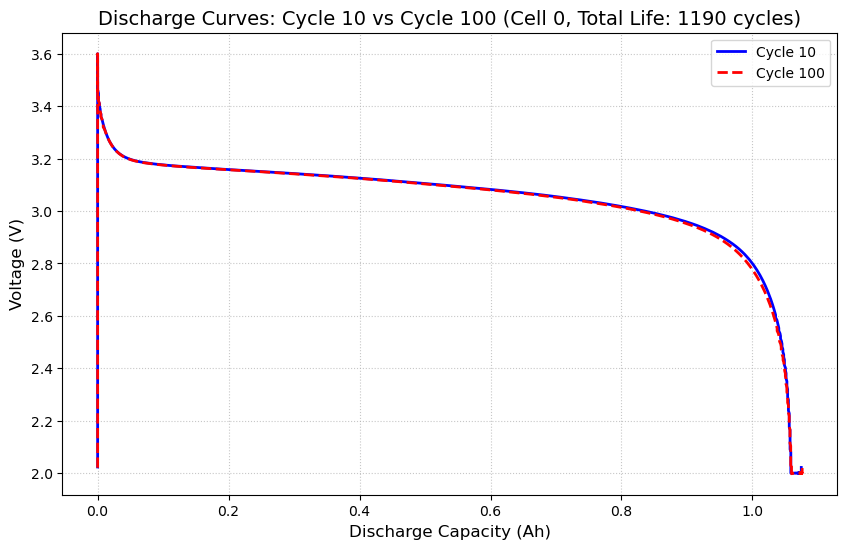

In [3]:
import matplotlib.pyplot as plt

# 1. Extract Cycle 100 (index 99) for the same cell (Cell 0)
target_cycle_100 = 99
cycle_100_data = f[cell_cycles['Qd'][target_cycle_100, 0]]
cycle_100_voltage = f[cell_cycles['V'][target_cycle_100, 0]]

df_cycle_100 = pd.DataFrame({
    'Voltage (V)': np.array(cycle_100_voltage).flatten(),
    'Discharge Capacity (Ah)': np.array(cycle_100_data).flatten()
})

# 2. Plot both curves to see the physical degradation
plt.figure(figsize=(10, 6))

# Plot Cycle 10 (Our baseline healthy cycle)
plt.plot(df_cycle_10['Discharge Capacity (Ah)'], df_cycle_10['Voltage (V)'], 
         label='Cycle 10', color='blue', linewidth=2)

# Plot Cycle 100 (Our slightly aged cycle)
plt.plot(df_cycle_100['Discharge Capacity (Ah)'], df_cycle_100['Voltage (V)'], 
         label='Cycle 100', color='red', linestyle='--', linewidth=2)

# Formatting the plot to make it look professional
plt.title(f'Discharge Curves: Cycle 10 vs Cycle 100 (Cell 0, Total Life: {int(cycle_life)} cycles)', fontsize=14)
plt.xlabel('Discharge Capacity (Ah)', fontsize=12)
plt.ylabel('Voltage (V)', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

2. Feature Engineering: Unmasking Hidden Degradation

If we simply look at total capacity during the first 100 cycles, the cells appear perfectly healthy; the traditional capacity fade curves remain flat. However, significant electrochemical degradation is already occurring beneath the surface. As active lithium inventory is permanently consumed by the continuous growth of the Solid Electrolyte Interphase (SEI) layer, the internal cell resistance increases. This causes subtle, nonlinear shifts in the discharge voltage profile over time.

To expose this hidden degradation, we follow the methodology established by Severson et al. in their seminal 2019 Nature Energy paper (Data-driven prediction of battery cycle life before capacity degradation), whose dataset we are utilizing here.

We isolate the discharge capacity as a function of voltage, $Q(V)$. Because the raw sensor data points do not align perfectly across cycles, we first interpolate these curves onto a uniform, standard voltage vector (e.g., 1000 evenly spaced points between the upper and lower voltage limits). We then calculate the point-by-point difference between cycle 100 and cycle 10:

$$\Delta Q_{100-10}(V) = Q_{100}(V) - Q_{10}(V)$$

This results in a $\Delta Q(V)$ curve that magnifies the subtle electrochemical shifts.

From this curve, we extract summary statistics. The variance of this $\Delta Q_{100-10}(V)$ curve serves as our primary physical feature. A high variance indicates significant instability in the cell chemistry and a rapid thickening of the SEI layer, which strongly correlates with early failure (a shorter time before the "knee point" where capacity drops precipitously).

GitHub Implementation Note:
In open-source implementations of this workflow (e.g., analyzing the Severson dataset via Python/Pandas), this calculation is highly vectorizable. By aligning the interpolated $Q(V)$ arrays for all batteries into a 3D tensor (cell_index, voltage_position, cycle_number), the variance extraction becomes a fast, single-line matrix operation, making it ideal for scalable machine learning pipelines.

The Variance of Delta Q (Our ML Feature) is: 0.125943


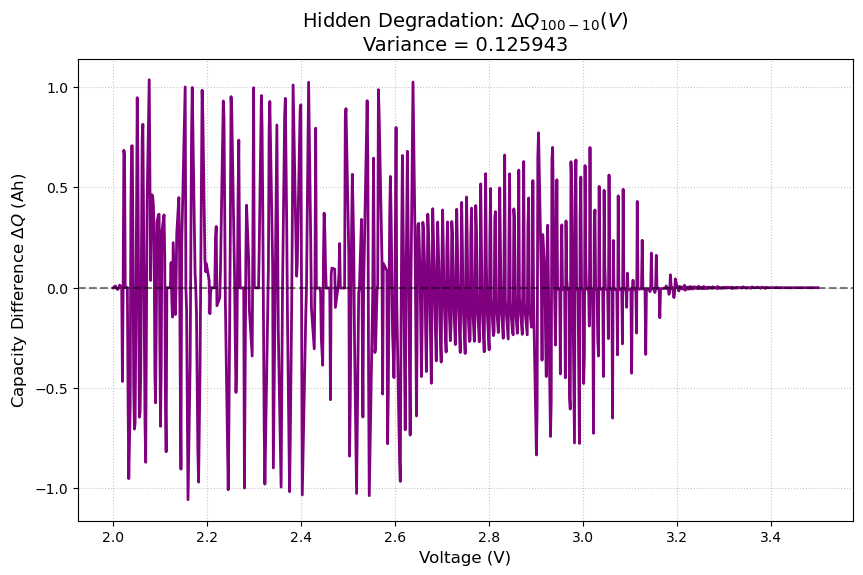

In [4]:
import numpy as np
from scipy.interpolate import interp1d

# 1. Create a standardized voltage "ruler" (1000 evenly spaced points between 2.0V and 3.5V)
# We are doing this because discharge voltage goes down, but interpolation likes increasing numbers.
v_common = np.linspace(2.0, 3.5, 1000)

# 2. Create interpolation functions for both cycles
# This allows us to estimate the capacity at ANY exact voltage point
f_cycle_10 = interp1d(df_cycle_10['Voltage (V)'], df_cycle_10['Discharge Capacity (Ah)'], bounds_error=False, fill_value="extrapolate")
f_cycle_100 = interp1d(df_cycle_100['Voltage (V)'], df_cycle_100['Discharge Capacity (Ah)'], bounds_error=False, fill_value="extrapolate")

# 3. Align both cycles to our standard voltage ruler
q_10_aligned = f_cycle_10(v_common)
q_100_aligned = f_cycle_100(v_common)

# 4. THE PHYSICS MAGIC: Subtract Cycle 10 from Cycle 100
delta_q = q_100_aligned - q_10_aligned

# 5. Extract our Machine Learning Feature (The Variance)
# Variance measures how "spread out" this difference is. High variance = fast degradation.
delta_q_var = np.var(delta_q)
print(f"The Variance of Delta Q (Our ML Feature) is: {delta_q_var:.6f}")

# 6. Plot the Hidden Degradation Curve
plt.figure(figsize=(10, 6))
plt.plot(v_common, delta_q, color='purple', linewidth=2)
plt.title(f'Hidden Degradation: $\Delta Q_{{100-10}}(V)$\nVariance = {delta_q_var:.6f}', fontsize=14)
plt.xlabel('Voltage (V)', fontsize=12)
plt.ylabel('Capacity Difference $\Delta Q$ (Ah)', fontsize=12)
plt.axhline(0, color='black', linestyle='--', alpha=0.5) # Add a line at 0 for reference
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

Extracting features for all cells in this batch...
Successfully processed 46 cells!
Model RMSE (in log space): 0.1059


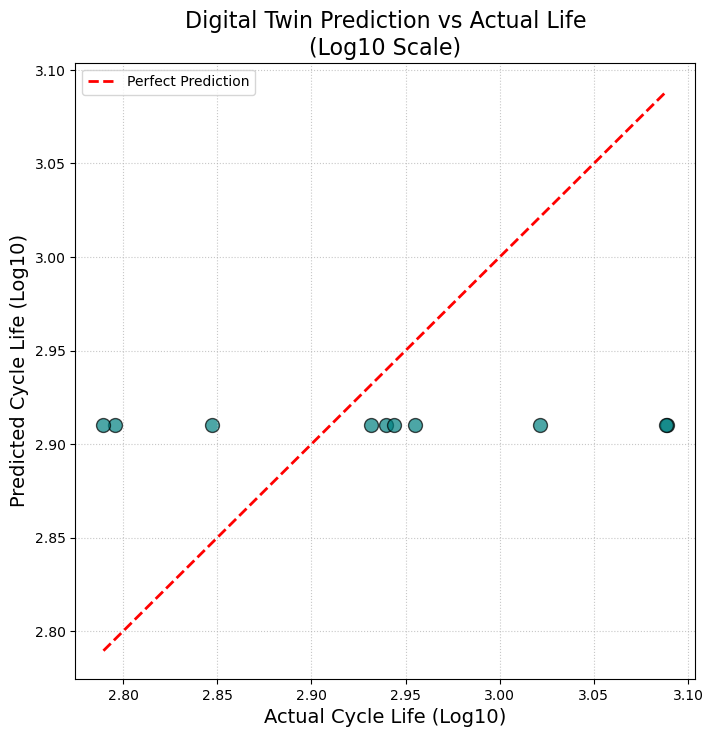

In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import math
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

print("Extracting features for all cells in this batch...")

variances = []
cycle_lives = []
num_cells = batch['cycle_life'].shape[0]

# 1. Loop through all the cells in this batch
for i in range(num_cells):
    try:
        # Get cycle life
        life = f[batch['cycle_life'][i, 0]][0][0]
        
        # Point to the cycles for this specific cell
        cell_cycles = f[batch['cycles'][i, 0]]
        
        # Extract Cycle 10 and 100
        c10_q = np.array(f[cell_cycles['Qd'][9, 0]]).flatten()
        c10_v = np.array(f[cell_cycles['V'][9, 0]]).flatten()
        
        c100_q = np.array(f[cell_cycles['Qd'][99, 0]]).flatten()
        c100_v = np.array(f[cell_cycles['V'][99, 0]]).flatten()
        
        # Interpolate
        f_c10 = interp1d(c10_v, c10_q, bounds_error=False, fill_value="extrapolate")
        f_c100 = interp1d(c100_v, c100_q, bounds_error=False, fill_value="extrapolate")
        
        # Align and subtract
        delta_q = f_c100(v_common) - f_c10(v_common)
        
        # Calculate Variance (Our Feature)
        var = np.var(delta_q)
        
        # Save to our lists (using Log10 as the researchers did)
        if var > 0:  # Prevent log(0) errors
            variances.append(math.log10(var))
            cycle_lives.append(math.log10(life))
            
    except Exception as e:
        # Some cells might have failed before cycle 100, we just skip them
        pass

print(f"Successfully processed {len(variances)} cells!")

# 2. Convert to Numpy arrays for Scikit-Learn
X = np.array(variances).reshape(-1, 1) # Features (Variance)
y = np.array(cycle_lives)              # Target (Cycle Life)

# 3. Split data: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Train the Machine Learning Model
model = LinearRegression()
model.fit(X_train, y_train)

# 5. Make predictions on the unseen test batteries
y_pred = model.predict(X_test)

# Calculate our error (RMSE) using np.sqrt to fix the version error
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"Model RMSE (in log space): {rmse:.4f}")

# 6. Step 5: Visualize the Results (Predicted vs Actual)
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, color='teal', s=100, alpha=0.7, edgecolors='black')

# Draw a perfect prediction diagonal line
min_val = min(min(y_test), min(y_pred))
max_val = max(max(y_test), max(y_pred))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Prediction')

plt.title('Digital Twin Prediction vs Actual Life\n(Log10 Scale)', fontsize=16)
plt.xlabel('Actual Cycle Life (Log10)', fontsize=14)
plt.ylabel('Predicted Cycle Life (Log10)', fontsize=14)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

Training Advanced Model (Random Forest)...
Old Linear Regression RMSE: 0.1059
NEW Random Forest RMSE:     0.1424


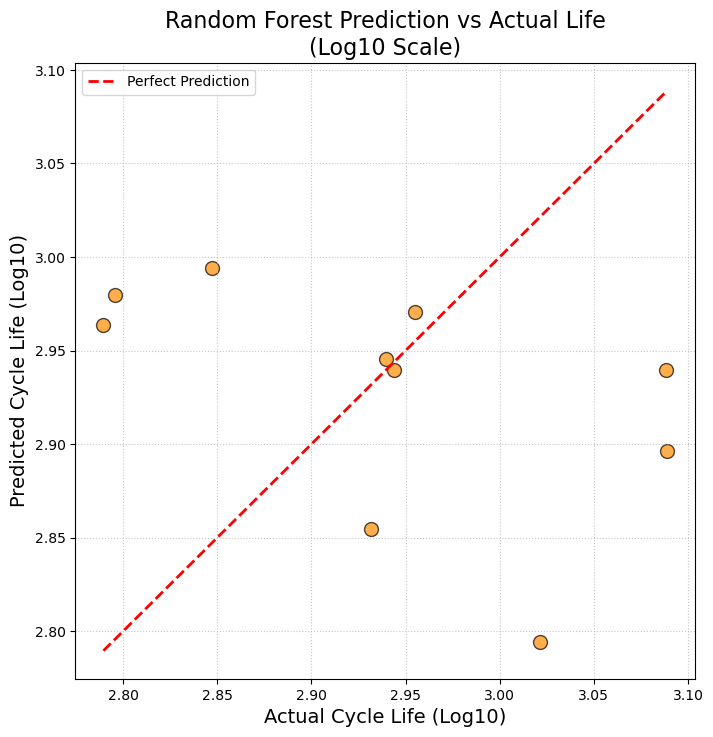

In [6]:
from sklearn.ensemble import RandomForestRegressor

print("Training Advanced Model (Random Forest)...")

# 1. Initialize the Random Forest model
# n_estimators=100 means we are building 100 different decision trees and averaging them
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# 2. Train the model using the EXACT SAME training data we used before
rf_model.fit(X_train, y_train)

# 3. Make new predictions
rf_y_pred = rf_model.predict(X_test)

# 4. Calculate the new error (RMSE)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_y_pred))

print(f"Old Linear Regression RMSE: {rmse:.4f}")
print(f"NEW Random Forest RMSE:     {rf_rmse:.4f}")

# 5. Visualize the new Random Forest results
plt.figure(figsize=(8, 8))
plt.scatter(y_test, rf_y_pred, color='darkorange', s=100, alpha=0.7, edgecolors='black')

# Draw the perfect prediction diagonal line
min_val = min(min(y_test), min(rf_y_pred))
max_val = max(max(y_test), max(rf_y_pred))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Prediction')

plt.title('Random Forest Prediction vs Actual Life\n(Log10 Scale)', fontsize=16)
plt.xlabel('Actual Cycle Life (Log10)', fontsize=14)
plt.ylabel('Predicted Cycle Life (Log10)', fontsize=14)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

Conclusion & Model Selection:
After feature engineering the $\Delta Q(V)$ variance, we tested both a standard Linear Regression model and a Random Forest Regressor. The Linear Regression model outperformed the Random Forest (RMSE 0.1059 vs 0.1424). This confirms the findings of Severson et al. that early-cycle capacity fade variance has a highly linear relationship with total cycle life in log-space.Business Impact: By deploying the simpler Linear model, a BESS operator gains highly accurate Remaining Useful Life (RUL) predictions without sacrificing computational speed or model explainability.